# PLANTILLA DE TRABAJO FINAL MODELO DE REGRESIÓN
# DATASET https://www.kaggle.com/datasets/taeefnajib/used-car-price-prediction-dataset

# PASO 1 INSTALAMOS LIBRERIAS

In [1]:
!pip install pyjanitor
import janitor

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 215.4/215.4 kB 4.1 MB/s eta 0:00:00


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
sns.set(style='whitegrid',context='notebook')

# PASO 2 CARGAMOS EL DATASET

In [4]:
df = pd.read_csv('/content/used_cars.csv')
df

,brand,model,model_year,milage,fuel_type,engine,transmission,ext_col,int_col,accident,clean_title,price
0,Ford,Utility Police Interceptor Base,2013,"51,000 mi.",E85 Flex Fuel,300.0HP 3.7L V6 Cylinder Engine Flex Fuel Capa...,6-Speed A/T,Black,Black,At least 1 accident or damage reported,Yes,"$10,300"
1,Hyundai,Palisade SEL,2021,"34,742 mi.",Gasoline,3.8L V6 24V GDI DOHC,8-Speed Automatic,Moonlight Cloud,Gray,At least 1 accident or damage reported,Yes,"$38,005"
2,Lexus,RX 350 RX 350,2022,"22,372 mi.",Gasoline,3.5 Liter DOHC,Automatic,Blue,Black,None reported,NaN,"$54,598"
3,INFINITI,Q50 Hybrid Sport,2015,"88,900 mi.",Hybrid,354.0HP 3.5L V6 Cylinder Engine Gas/Electric H...,7-Speed A/T,Black,Black,None reported,Yes,"$15,500"
4,Audi,Q3 45 S line Premium Plus,2021,"9,835 mi.",Gasoline,2.0L I4 16V GDI DOHC Turbo,8-Speed Automatic,Glacier White Metallic,Black,None reported,NaN,"$34,999"
...,...,...,...,...,...,...,...,...,...,...,...,...
4004,Bentley,Continental GT Speed,2023,714 mi.,Gasoline,6.0L W12 48V PDI DOHC Twin Turbo,8-Speed Automatic with Auto-Shift,C / C,Hotspur,None reported,Yes,"$349,950"
4005,Audi,S4 3.0T Premium Plus,2022,"10,900 mi.",Gasoline,349.0HP 3.0L V6 Cylinder Engine Gasoline Fuel,Transmission w/Dual Shift Mode,Black,Black,None reported,Yes,"$53,900"
4006,Porsche,Taycan,2022,"2,116 mi.",NaN,Electric,Automatic,Black,Black,None reported,NaN,"$90,998"
4007,Ford,F-150 Raptor,2020,"33,000 mi.",Gasoline,450.0HP 3.5L V6 Cylinder Engine Gasoline Fuel,A/T,Blue,Black,None reported,Yes,"$62,999"


# PASO 3 - ANALISIS EXPLORATORIO DE DATOS

In [8]:
# tipos de datos
df.dtypes.value_counts()

,count
object,11
int64,1


In [9]:
df.dtypes

,0
brand,object
model,object
model_year,int64
milage,object
fuel_type,object
engine,object
transmission,object
ext_col,object
int_col,object
accident,object


## CONVERTIMOS A TIPOS DE CORRECTO

In [ ]:
df['milage'] = df['milage'].str.replace(' mi.', '', regex=False).str.replace(',', '', regex=False).astype(float)
df['price'] = df['price'].str.replace('$', '', regex=False).str.replace(',', '', regex=False).astype(float)

In [13]:
df['engine_size'] = df['engine'].str.extract(r'(\d+\.?\d*)\s*(?:L|Liter)').astype(float)
display(df[['engine', 'engine_size']].head())

,engine,engine_size
0,300.0HP 3.7L V6 Cylinder Engine Flex Fuel Capa...,3.7
1,3.8L V6 24V GDI DOHC,3.8
2,3.5 Liter DOHC,3.5
3,354.0HP 3.5L V6 Cylinder Engine Gas/Electric H...,3.5
4,2.0L I4 16V GDI DOHC Turbo,2.0


In [ ]:
df['gasoline'] = df['fuel_type'].str.contains('Gasoline', case=False, na=False)


In [22]:
df['transmission'].value_counts()

,count
transmission,
A/T,1037
8-Speed A/T,406
Transmission w/Dual Shift Mode,398
6-Speed A/T,362
6-Speed M/T,248
...,...
10-Speed Automatic with Overdrive,1
9-Speed Automatic with Auto-Shift,1
SCHEDULED FOR OR IN PRODUCTION,1


In [ ]:
df['transmission_encoded'] = df['transmission'].str.contains('Automatic', case=False, na=False).astype(int)


# VERIFICAMOS VALORES NULOS

In [26]:
df.isna().sum()

,0
brand,0
model,0
model_year,0
milage,0
fuel_type,170
engine,0
transmission,0
ext_col,0
int_col,0
accident,113


In [25]:
mean_engine_size = df['engine_size'].mean()
df['engine_size'].fillna(mean_engine_size, inplace=True)

/tmp/ipython-input-362279764.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['engine_size'].fillna(mean_engine_size, inplace=True)


In [27]:
df.dtypes

,0
brand,object
model,object
model_year,int64
milage,float64
fuel_type,object
engine,object
transmission,object
ext_col,object
int_col,object
accident,object


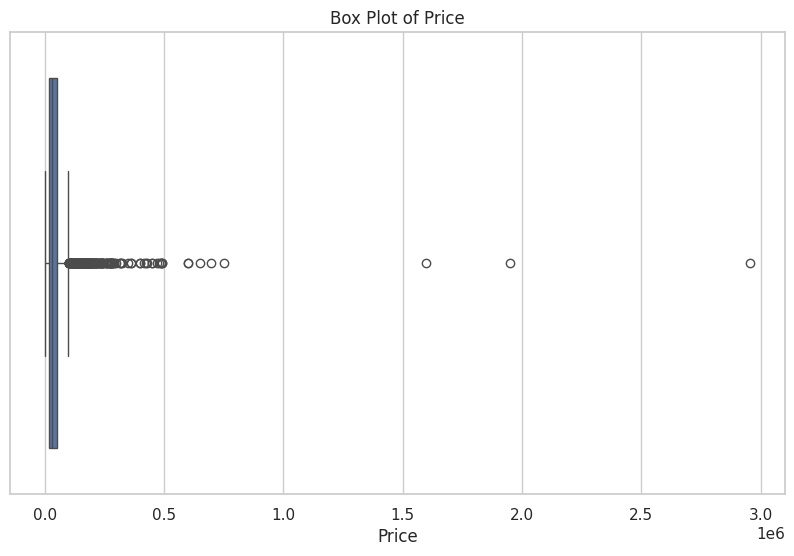

In [32]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.boxplot(x=df['price'])
plt.title('Box Plot of Price')
plt.xlabel('Price')
plt.show()

In [33]:
Q1 = df['price'].quantile(0.25)
Q3 = df['price'].quantile(0.75)
IQR = Q3 - Q1

# Define bounds for outliers
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Filter the DataFrame to remove outliers
df_filtered = df[(df['price'] >= lower_bound) & (df['price'] <= upper_bound)].copy()

display(f"Original number of rows: {len(df)}")
display(f"Number of rows after removing outliers: {len(df_filtered)}")

'Original number of rows: 4009'

'Number of rows after removing outliers: 3765'

## SELECCIONAMOS SOLO LOS VALORES NÚMERICOS

In [35]:
df_clean = df.select_dtypes(include='number').copy()
df_clean

,model_year,milage,price,engine_size,fuel_type_encoded,transmission_encoded
0,2013,51000.0,10300.0,3.700000,0,0
1,2021,34742.0,38005.0,3.800000,1,1
2,2022,22372.0,54598.0,3.500000,1,1
3,2015,88900.0,15500.0,3.500000,0,0
4,2021,9835.0,34999.0,2.000000,1,1
...,...,...,...,...,...,...
4004,2023,714.0,349950.0,6.000000,1,1
4005,2022,10900.0,53900.0,3.000000,1,0
4006,2022,2116.0,90998.0,3.684454,0,1
4007,2020,33000.0,62999.0,3.500000,1,0


## CORRELACIONES

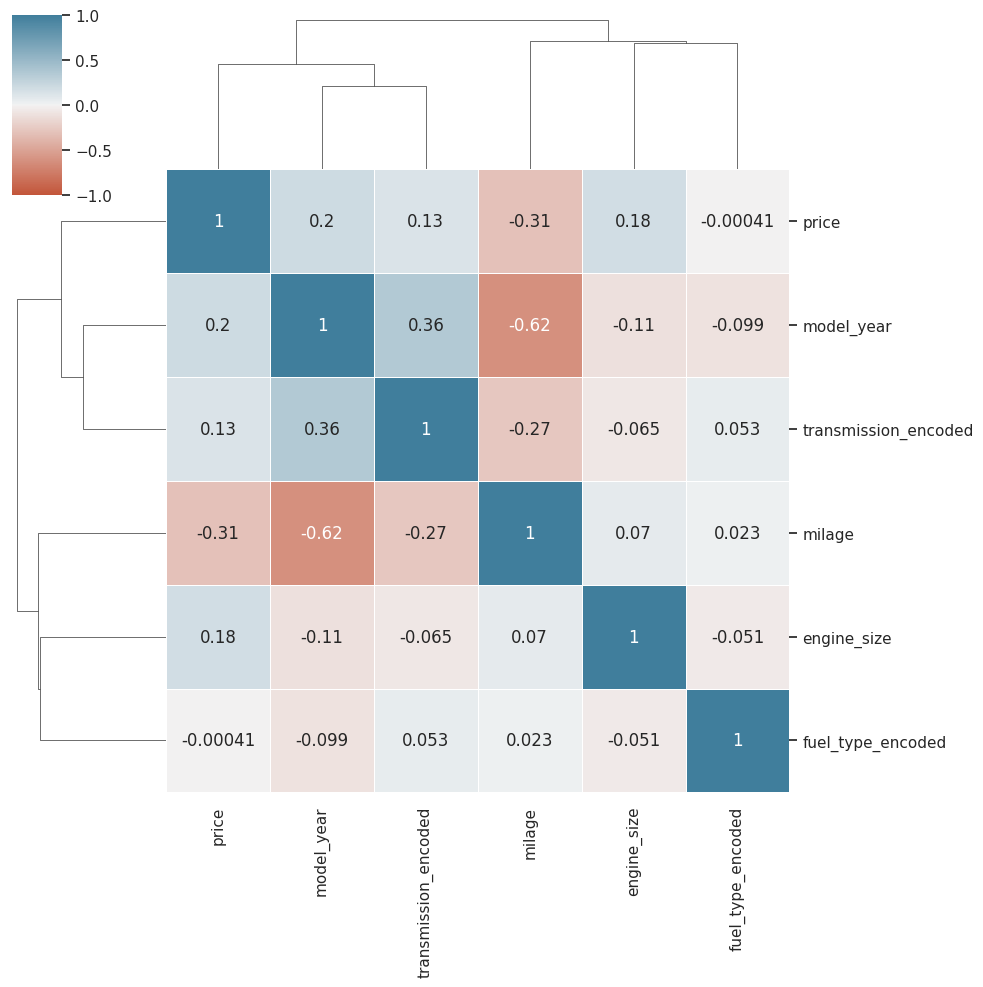

In [36]:
sns.clustermap(
    data=df_clean.corr(numeric_only=True),
    cmap=sns.diverging_palette(20,230,as_cmap=True),
    center=0,
    vmin=-1,
    vmax=1,
    linewidths=0.5,
    cbar_kws={'shrink':0.5},
    annot=True
)